In [1]:
# Install UCI ML Repo loader
!pip install ucimlrepo

In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# UCI dataset loader
from ucimlrepo import fetch_ucirepo

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [4]:
# Load Dataset from UCI

# Fetch dataset using UCI ML Repo
diabetes = fetch_ucirepo(id=296)

# Features and target
X = diabetes.data.features
y = diabetes.data.targets

# Combine into one DataFrame
df = pd.concat([X, y], axis=1)

df.head()

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# Dataset Inspection

df.shape

(101766, 48)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [7]:
df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [9]:
# Data Cleaning & Preprocessing

# Replace Missing Value Indicator
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

In [10]:
# Drop High-Missing Columns
# Columns with excessive missing values
df.drop(
    columns=["weight", "payer_code", "medical_specialty"],
    inplace=True
)

In [11]:
# Supervised Learning Setup (Decision Tree)
# Target Variable Definition
df["readmitted"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

In [12]:
# Feature Selection
features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

X = df[features]
y = df["readmitted"]

In [13]:
# Handle Missing Values
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=features)

In [14]:
# Train–Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [15]:
# Decision Tree Model
# Train Model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=50, random_state=42)

In [16]:
# Predictions & Metrics
y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8888845216571024
Precision: 0.603448275862069
Recall: 0.012328284607256075
F1 Score: 0.02416292716603383
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     22603
           1       0.60      0.01      0.02      2839

    accuracy                           0.89     25442
   macro avg       0.75      0.51      0.48     25442
weighted avg       0.86      0.89      0.84     25442



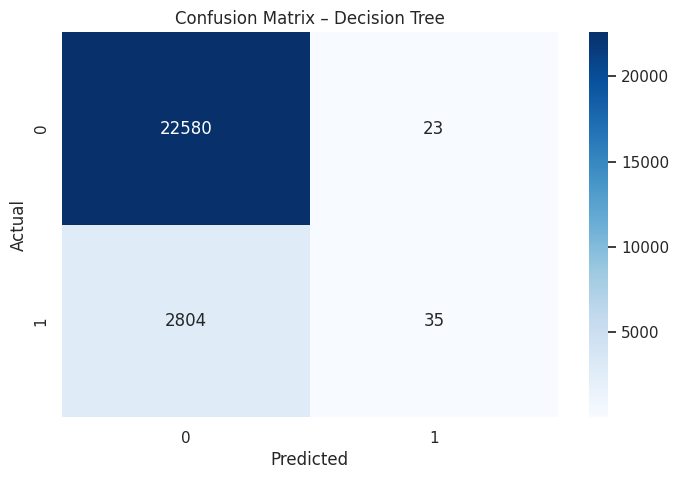

In [17]:
# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

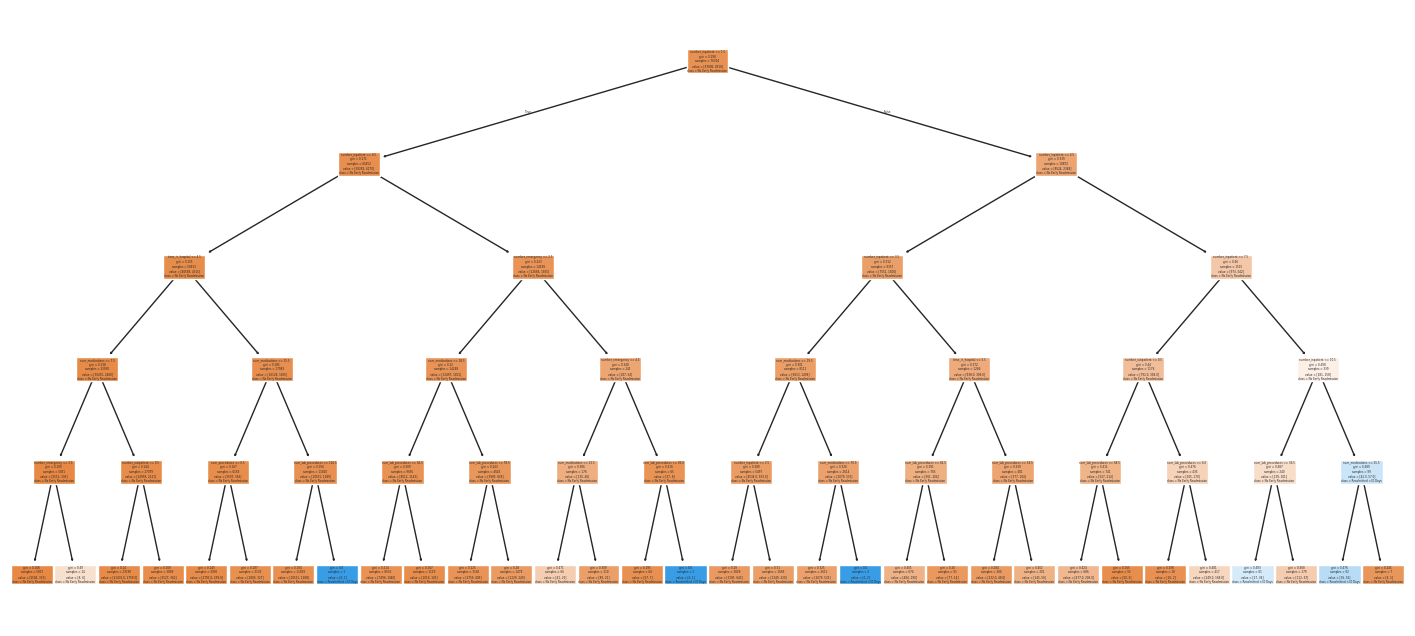

In [18]:
# Decision Tree Visualization
plt.figure(figsize=(18, 8))
plot_tree(
    dt_model,
    feature_names=features,
    class_names=["No Early Readmission", "Readmitted <30 Days"],
    filled=True
)
plt.show()


In [19]:
# Unsupervised Learning: K-Means Clustering
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

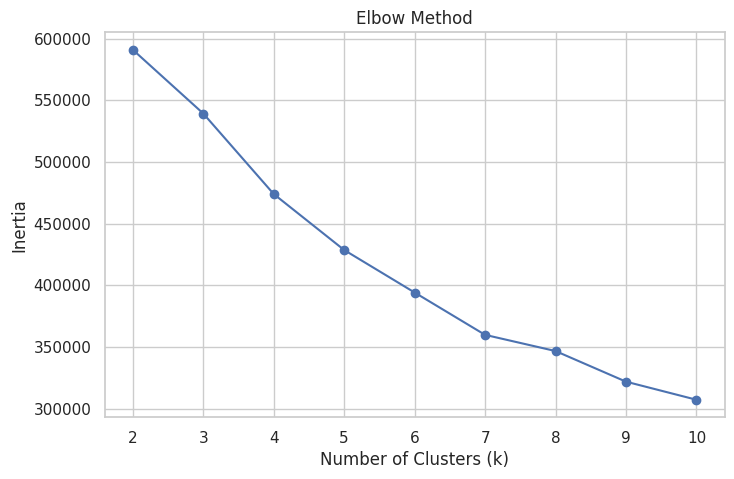

In [20]:
# Elbow Method
inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [21]:
# Fit K-Means (k = 3)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X["Cluster"] = clusters

In [22]:
# Silhouette Score
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.1527689251094819


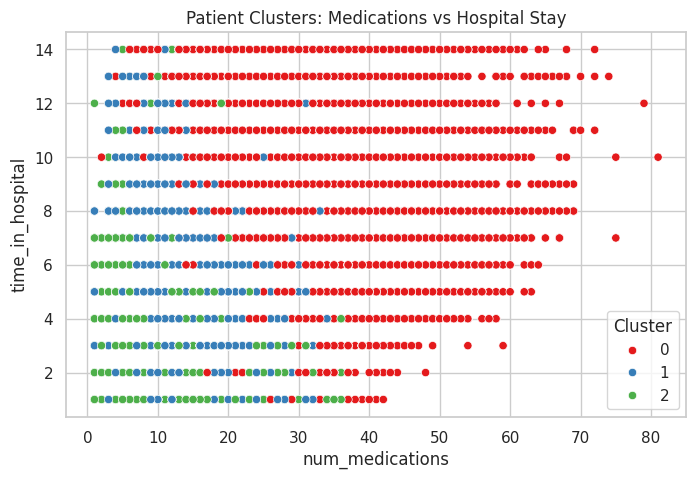

In [23]:
# Cluster Visualization
sns.scatterplot(
    data=X,
    x="num_medications",
    y="time_in_hospital",
    hue="Cluster",
    palette="Set1"
)
plt.title("Patient Clusters: Medications vs Hospital Stay")
plt.show()

In [24]:
# Cluster Summary
cluster_summary = X.groupby("Cluster").mean()
cluster_summary

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient
Cluster,,,,,,,
0,8.032750,55.100663,2.984831,25.649024,0.305330,0.142367,0.609083
1,4.010309,52.962488,0.463144,14.286387,0.480928,0.313121,0.963191
2,2.745610,24.978736,1.391670,12.465560,0.279251,0.098590,0.278185
